# 03 - Exploratory Data Analysis (EDA)

# Digikala Content Analytics & AI Insight Platform


## Business Context


E-commerce platforms generate massive amounts of product data.
Analyzing this data helps teams understand:

- Product performance
- Customer satisfaction
- Content quality opportunities
- Marketplace risks


This notebook performs exploratory analysis on Digikala product data
to discover business insights that can support content and product decisions.



## Objective


The main objectives are:


- Analyze marketplace product distribution
- Identify high-performing categories and brands
- Understand rating patterns
- Analyze pricing behavior
- Detect potential marketplace quality issues
- Generate hypotheses for Content Analytics


## Business Questions


1. Which categories have the highest marketplace presence?


2. Which brands perform better based on customer ratings?


3. Does price affect customer satisfaction?


4. Which categories have higher fake product rates?


5. Where are content optimization opportunities?


## Workflow


Processed Data

↓

Marketplace Analysis

↓

Product Quality Analysis

↓

Price Analysis

↓

Business Insights


In [12]:
# Import libraries

import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns


import warnings

warnings.filterwarnings("ignore")


pd.set_option(
    "display.max_columns",
    None
)


plt.rcParams["figure.figsize"] = (10,6)


print("Libraries imported successfully")

Libraries imported successfully


# 1. Load Processed Dataset


The cleaned dataset generated in Notebook 02
is used for analysis.


Using processed data ensures:

- Data consistency
- Reproducibility
- Reliable insights


In [13]:
DATA_PATH = "../data/processed/"


products = pd.read_csv(
    DATA_PATH + 
    "products_clean.csv"
)


products.head()

,id,title_fa,Rate,Rate_cnt,Category1,Category2,Brand,Price,Seller,Is_Fake,min_price_last_month,sub_category
0,7096438,آبسلانگ مدل s5 بسته 250 عددی,90,4,آبسلانگ,NaN,متفرقه,634800,سلامت ساز راد,False,0,beauty
1,2845119,آبسلانگ مدل M-1 بسته 400 عددی,84,217,آبسلانگ,NaN,متفرقه,818800,مهر افزون,False,0,beauty
2,6117745,آبسلانگ مدل m50 مجموعه 500 عددی,88,14,آبسلانگ,NaN,متفرقه,920000,یانگوم,False,0,beauty
3,1912926,استند ابسلانگ مدل S01,78,25,آبسلانگ,NaN,متفرقه,1100000,بهراد طب بیدار,False,0,beauty
4,6335462,آبسلانگ نوری تسلامد مدل All-in-One,84,25,آبسلانگ,NaN,تسلا مد,1530000,دیجی‌کالا,False,0,beauty


In [14]:
products.shape

(960367, 12)

# 2. Dataset Overview


Understanding available features
before analysis.


In [15]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 960367 entries, 0 to 960366
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   id                    960367 non-null  int64 
 1   title_fa              960367 non-null  object
 2   Rate                  960367 non-null  int64 
 3   Rate_cnt              960367 non-null  int64 
 4   Category1             960367 non-null  object
 5   Category2             778477 non-null  object
 6   Brand                 960367 non-null  object
 7   Price                 960367 non-null  int64 
 8   Seller                960169 non-null  object
 9   Is_Fake               960367 non-null  bool  
 10  min_price_last_month  960367 non-null  int64 
 11  sub_category          960367 non-null  object
dtypes: bool(1), int64(5), object(6)
memory usage: 81.5+ MB


In [16]:
products.describe()

,id,Rate,Rate_cnt,Price,min_price_last_month
count,9.603670e+05,960367.000000,960367.000000,9.603670e+05,9.603670e+05
mean,7.923533e+06,30.833221,20.935757,9.133201e+06,4.655652e+05
std,3.542440e+06,40.141616,218.993884,5.162435e+07,1.123545e+07
min,7.602000e+03,0.000000,0.000000,0.000000e+00,0.000000e+00
25%,5.180719e+06,0.000000,0.000000,7.380000e+05,0.000000e+00
50%,8.693870e+06,0.000000,0.000000,1.700000e+06,0.000000e+00
75%,1.101106e+07,80.000000,2.000000,4.580000e+06,0.000000e+00
max,1.277376e+07,100.000000,30438.000000,8.499990e+09,7.645500e+09


# 3. Marketplace Category Analysis


Categories represent different business segments.

Understanding category distribution helps:

- Prioritize content improvements
- Identify important marketplace areas
- Compare category performance


In [17]:
category_analysis = (

    products
    .groupby("Category1")
    .agg(

        product_count=("id","count"),

        avg_rating=("Rate","mean"),

        avg_price=("Price","mean")

    )

    .sort_values(
        "product_count",
        ascending=False
    )

)


category_analysis.head(10)

,product_count,avg_rating,avg_price
Category1,,,
لباس زنانه,78012,23.452212,4.043394e+06
اکسسوری زنانه,57643,19.560710,1.039514e+07
لباس مردانه,56079,26.281460,4.821785e+06
اکسسوری زنانه و مردانه,53712,24.744936,6.296250e+06
اسباب بازی,42972,34.919436,4.532727e+06
دخترانه,35263,23.059978,2.163337e+06
اکسسوری مردانه,34279,23.566557,2.436360e+07
زیورآلات طلا زنانه,32903,8.345257,4.747312e+07
کتاب چاپی غیر فارسی,31792,10.682939,2.774024e+06


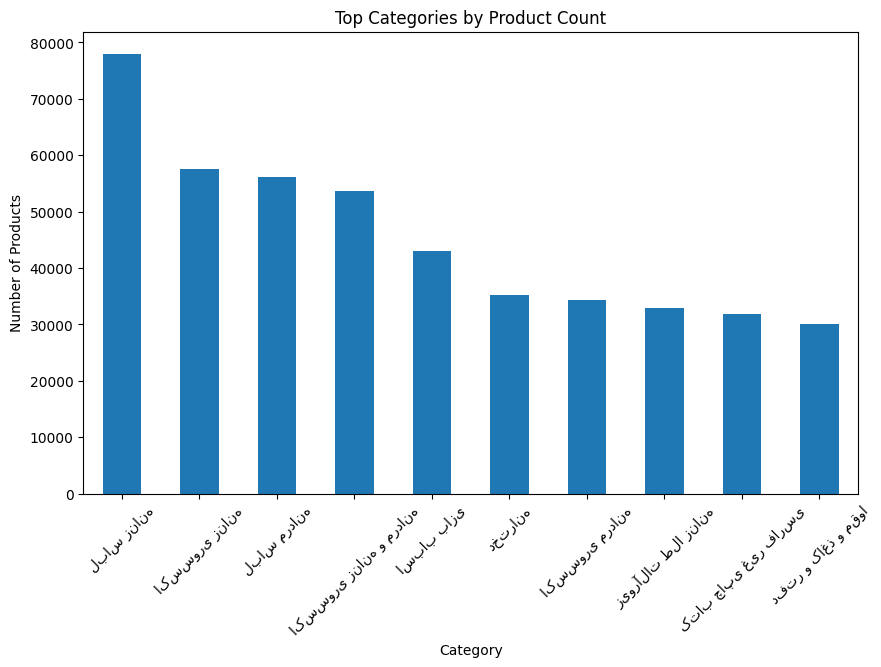

In [18]:
top_categories = (
    category_analysis
    .head(10)
)


top_categories["product_count"].plot(
    kind="bar"
)


plt.title(
    "Top Categories by Product Count"
)


plt.xlabel(
    "Category"
)


plt.ylabel(
    "Number of Products"
)


plt.xticks(rotation=45)

plt.show()

# 4. Brand Performance Analysis


Brands can have different levels of:

- Product availability
- Customer satisfaction
- Pricing strategy



In [19]:
brand_analysis = (

    products
    .groupby("Brand")
    .agg(

        product_count=("id","count"),

        avg_rating=("Rate","mean"),

        avg_price=("Price","mean")

    )

    .sort_values(
        "product_count",
        ascending=False
    )

)


brand_analysis.head(10)

,product_count,avg_rating,avg_price
Brand,,,
متفرقه,533539,26.579785,6.459095e+06
لیردا,13798,1.267430,9.819147e+06
الن نار,12308,0.511212,4.181470e+07
خندالو,7687,7.213477,9.686130e+05
کرابو,7295,3.871419,3.422915e+07
اچ اند ام,7095,9.470049,7.390394e+06
ترمه ۱,6534,11.802571,2.203432e+06
اسمارا,5935,28.080539,4.702733e+06
27,5220,11.001916,1.160511e+06


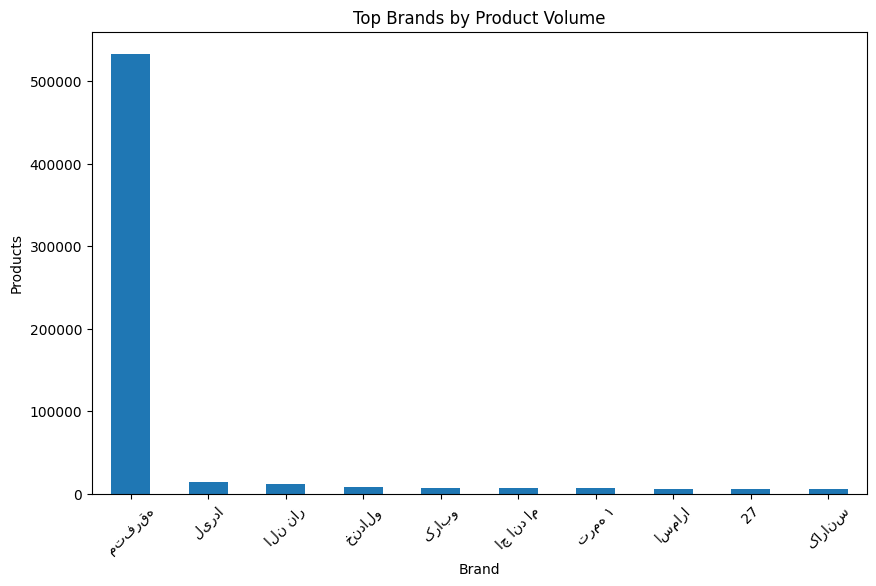

In [20]:
brand_analysis.head(10)["product_count"].plot(
    kind="bar"
)


plt.title(
    "Top Brands by Product Volume"
)


plt.xlabel(
    "Brand"
)


plt.ylabel(
    "Products"
)


plt.xticks(rotation=45)

plt.show()

# 5. Seller Analysis


Seller performance is important for marketplace quality.


Questions:

- Which sellers dominate the marketplace?
- Are some sellers associated with lower ratings?


In [21]:
seller_analysis = (

    products
    .groupby("Seller")
    .agg(

        products=("id","count"),

        avg_rating=("Rate","mean")

    )

    .sort_values(
        "products",
        ascending=False
    )

)


seller_analysis.head(10)

,products,avg_rating
Seller,,
بوکم,20731,2.522888
استودیو هنری ژانو,18451,7.992304
لیردا گلد,17774,4.079104
نارگلد گالری,13598,3.939991
کتابکالا,12542,68.093765
نوین کالا,11341,29.454369
دیجی‌کالا,9808,55.794046
کتاب سالم,8760,62.863699
خندالو,7687,7.213477


# 6. Product Rating Analysis


Ratings are an important customer satisfaction indicator.



In [23]:
products["Rate"].describe()

count    960367.000000
mean         30.833221
std          40.141616
min           0.000000
25%           0.000000
50%           0.000000
75%          80.000000
max         100.000000
Name: Rate, dtype: float64

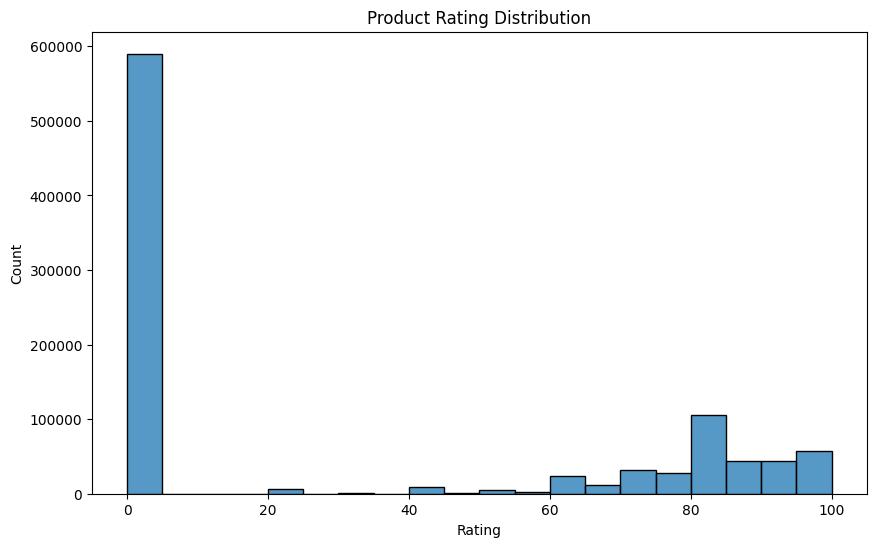

In [24]:
sns.histplot(
    products["Rate"],
    bins=20
)


plt.title(
    "Product Rating Distribution"
)


plt.xlabel(
    "Rating"
)


plt.show()

# 7. Fake Product Analysis


Fake products can damage:

- Customer trust
- Marketplace reputation
- Brand value


The dataset provides an indicator
for identifying fake products.


In [25]:
fake_analysis = (
    products["Is_Fake"]
    .value_counts()
)


fake_analysis

Is_Fake
False    911947
True      48420
Name: count, dtype: int64

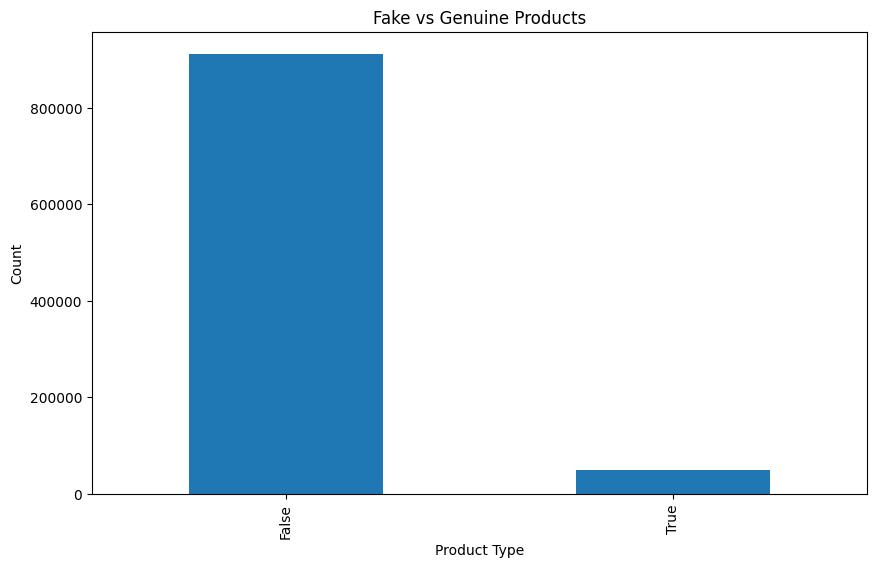

In [26]:
fake_analysis.plot(
    kind="bar"
)


plt.title(
    "Fake vs Genuine Products"
)


plt.xlabel(
    "Product Type"
)


plt.ylabel(
    "Count"
)


plt.show()

In [27]:
fake_category = (

    products
    .groupby("Category1")
    ["Is_Fake"]
    .mean()
    .sort_values(
        ascending=False
    )

)


fake_category.head(10)

Category1
آلبوم عکس                       0.428571
کفش مردانه                      0.317678
کفش زنانه و مردانه              0.272463
لوازم سفر                       0.269524
لباس مردانه                     0.183348
کفش زنانه                       0.153831
ورزش های هوازی و تناسب اندام    0.153779
پسرانه                          0.123351
لباس زنانه                      0.115046
اصلاح موی گوش، بینی و ابرو      0.114286
Name: Is_Fake, dtype: float64

# 8. Price Analysis


Price analysis helps understand:

- Market segments
- Premium products
- Outliers


In [28]:
products["Price"].describe()

count    9.603670e+05
mean     9.133201e+06
std      5.162435e+07
min      0.000000e+00
25%      7.380000e+05
50%      1.700000e+06
75%      4.580000e+06
max      8.499990e+09
Name: Price, dtype: float64

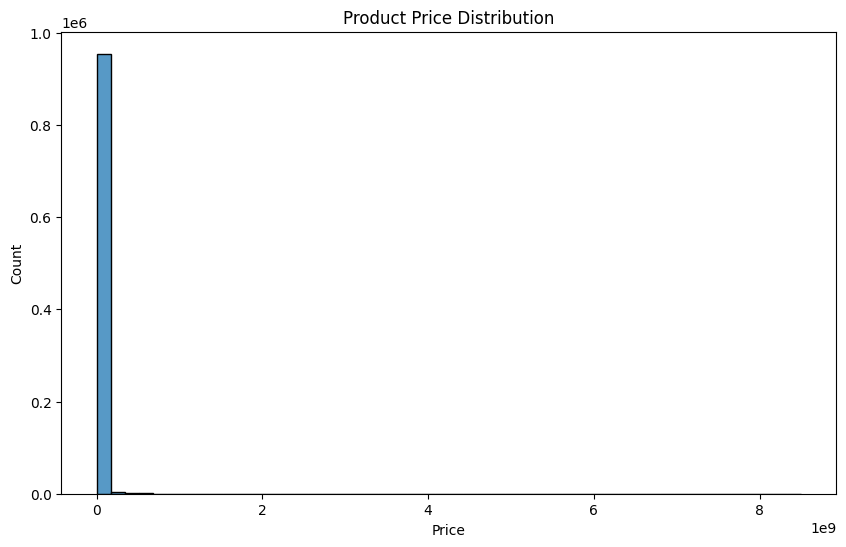

In [29]:
sns.histplot(
    products["Price"],
    bins=50
)


plt.title(
    "Product Price Distribution"
)


plt.xlabel(
    "Price"
)


plt.show()

# 9. Price and Rating Relationship


We investigate whether product price
is related to customer satisfaction.


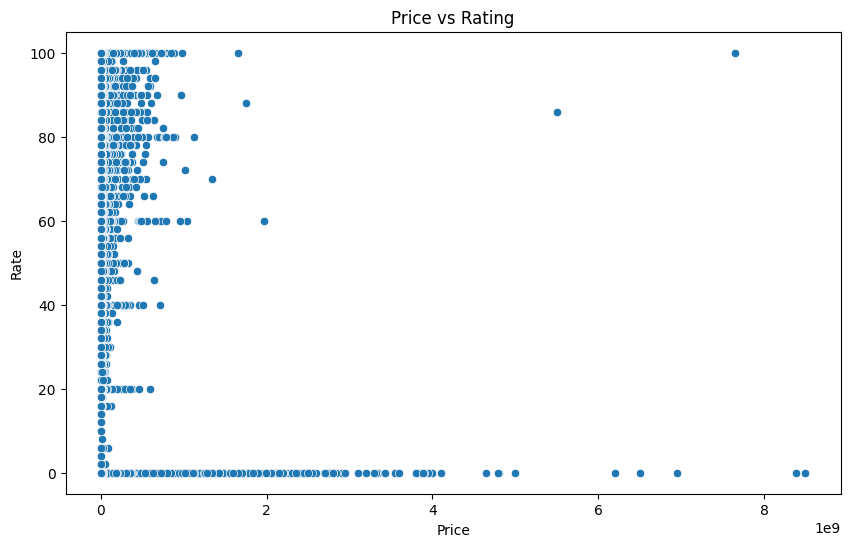

In [31]:
sns.scatterplot(
    data=products,

    x="Price",

    y="Rate"
)


plt.title(
    "Price vs Rating"
)


plt.show()

# 10. Content Analytics Insights


Based on EDA, potential business insights include:


## Category Optimization

Identify categories with:

- High product volume
- Low ratings
- Content improvement opportunities


## Brand Analysis

Find brands with:

- High customer satisfaction
- Strong marketplace presence


## Marketplace Quality

Detect categories with:

- Higher fake product probability
- Lower customer trust


## Pricing Strategy

Understand relationship between:

- Price
- Customer satisfaction



# 11. Summary & Next Steps


## Completed:


✔ Marketplace distribution analysis

✔ Category performance analysis

✔ Brand performance analysis

✔ Rating analysis

✔ Fake product investigation

✔ Price analysis



## Next Notebook:


# 04 - Content Quality Analytics


The next step is to create measurable content KPIs:


- Content Quality Score

- Product Completeness Score

- Category Content Ranking

- Content Improvement Recommendations
